In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, log_loss, confusion_matrix, classification_report

# Base models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.ensemble import BaggingClassifier, VotingClassifier, StackingClassifier, ExtraTreesClassifier

# Boosting
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [86]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
sample_sub = pd.read_csv('sample_submission.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()

Train shape: (8693, 14)
Test shape: (4277, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


##Khai phá dữ liệu :D

<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   str    
 1   HomePlanet    8492 non-null   str    
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   str    
 4   Destination   8511 non-null   str    
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   str    
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(5)
memory usage: 891.5+ KB
Missing in train:
 HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomSe

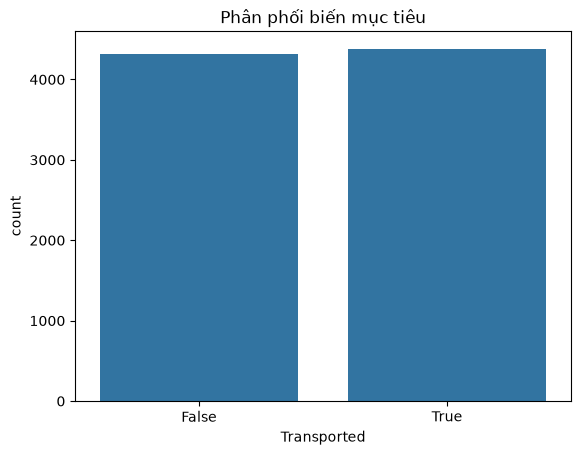

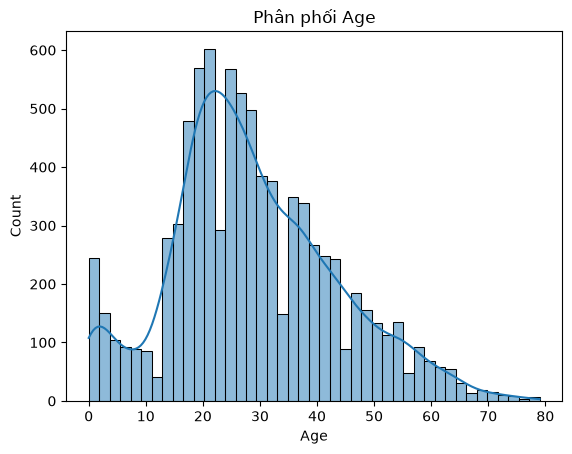

Cabin
G/734/S     8
E/13/S      7
B/11/S      7
C/21/P      7
G/109/P     7
B/82/S      7
C/137/S     7
F/1194/P    7
D/176/S     7
B/201/P     7
Name: count, dtype: int64

In [87]:
train.info()
train.describe(include='all')

missing_train = train.isnull().sum()
missing_test = test.isnull().sum()
print("Missing in train:\n", missing_train[missing_train>0])
print("\nMissing in test:\n", missing_test[missing_test>0])

sns.countplot(x='Transported', data=train)
plt.title('Phân phối biến mục tiêu')
plt.show()

# vd: Age
sns.histplot(train['Age'].dropna(), kde=True)
plt.title('Phân phối Age')
plt.show()

# Cabin có thể tách thành Deck, Number, Side
train['Cabin'].value_counts().head(10)

Preprocessing 1: 

Tách PassengerId thành Group và Number (vì id có dạng ggggg_nn)

Tách Cabin thành Deck (chữ cái đầu), Num (số), Side (P/S)

Tổng số tiền chi tiêu: TotalSpent = RoomService + FoodCourt + ShoppingMall + Spa + VRDeck

Số lượng dịch vụ đã sử dụng (ServiceCount)

In [88]:
def apply_cryo_spending(df):
    df = df.copy()
    spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    cryosleep_mark = df['CryoSleep'] == True
    for col in spend_cols:
        df.loc[cryosleep_mark, col] = 0
    df['TotalSpent'] = df[spend_cols].sum(axis=1)
    spend_mark = df['TotalSpent'] > 0
    df.loc[spend_mark, 'CryoSleep'] = False
    df = df.drop('TotalSpent', axis=1)
    for col in spend_cols:
        df[col] = df[col].fillna(0)
    return df

def fill_missing_by_group(df, col):
    df[col] = df.groupby('Group')[col].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan))
    return df

def preprocess(df, is_train=True, train_stats=None):
    df = df.copy()
    
    # Tách Group và Number
    df[['Group', 'Number']] = df['PassengerId'].str.split('_', expand=True)
    df['Group'] = df['Group'].astype(int)
    df['Number'] = df['Number'].astype(int)
    
    # Số lượng người trong nhóm
    group_size = df.groupby('Group')['PassengerId'].transform('count')
    df['GroupSize'] = group_size
    df['IsAlone'] = (df['GroupSize'] == 1).astype(int)
    
    df = apply_cryo_spending(df)
    df = fill_missing_by_group(df, 'HomePlanet')
    
    df['Cabin'] = df['Cabin'].fillna('Z/9999/Z')
    df[['Deck', 'CabinNum', 'Side']] = df['Cabin'].str.split('/', expand=True)
    
    df = fill_missing_by_group(df, 'Deck')
    df = fill_missing_by_group(df, 'Side')
    
    spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    df[spend_cols] = df[spend_cols].fillna(0)
    
    df['TotalSpent'] = df[spend_cols].sum(axis=1)
    
    # log transform
    for col in spend_cols:
        df[col] = np.log1p(df[col])
    
    # Điền Age theo HomePlanet và CryoSleep
    if is_train:
        df['Age'] = df.groupby(['HomePlanet', 'CryoSleep'])['Age'].transform(
            lambda x: x.fillna(x.median() if not pd.isna(x.median()) else df['Age'].median())
        )
        df['Age'] = df['Age'].fillna(df['Age'].median())
        
        df = fill_missing_by_group(df, 'CryoSleep')
        df = fill_missing_by_group(df, 'VIP')
        
        df['CryoSleep'] = df['CryoSleep'].fillna(False).astype(int)
        df['VIP'] = df['VIP'].fillna(False).astype(int)
        
        train_stats = {
            'age_median_by_planet_cryo': df.groupby(['HomePlanet', 'CryoSleep'])['Age'].median().to_dict(),
            'age_global_median': df['Age'].median(),
            'cryosleep_mode': df['CryoSleep'].mode()[0],
            'vip_mode': df['VIP'].mode()[0]
        }
    else:
        if train_stats is not None:
            cryo_mode = train_stats['cryosleep_mode']
            df['CryoSleep'] = df['CryoSleep'].fillna(cryo_mode).astype(int)
            df['VIP'] = df['VIP'].fillna(train_stats['vip_mode']).astype(int)
            df['Age'] = df.apply(
                lambda row: train_stats['age_median_by_planet_cryo'].get(
                    (row['HomePlanet'], row['CryoSleep']),
                    train_stats['age_global_median']
                ) if pd.isna(row['Age']) else row['Age'],
                axis=1
            )
        else:
            df['CryoSleep'] = df['CryoSleep'].fillna(False).astype(int)
            df['VIP'] = df['VIP'].fillna(False).astype(int)
            df['Age'] = df.groupby(['HomePlanet', 'CryoSleep'])['Age'].transform(
                lambda x: x.fillna(x.median() if not pd.isna(x.median()) else df['Age'].median())
            )
            df['Age'] = df['Age'].fillna(df['Age'].median())
    
    return df, train_stats

# Gọi train trước để có train_stats
train_processed, train_stats = preprocess(train)
test_processed, _ = preprocess(test, is_train=False, train_stats=train_stats)

train_processed.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,...,Name,Transported,Group,Number,GroupSize,IsAlone,Deck,CabinNum,Side,TotalSpent
0,0001_01,Europa,0,B/0/P,TRAPPIST-1e,39.0,0,0.000000,0.000000,0.000000,...,Maham Ofracculy,False,1,1,1,1,B,0,P,0.0
1,0002_01,Earth,0,F/0/S,TRAPPIST-1e,24.0,0,4.700480,2.302585,3.258097,...,Juanna Vines,True,2,1,1,1,F,0,S,736.0
2,0003_01,Europa,0,A/0/S,TRAPPIST-1e,58.0,1,3.784190,8.182280,0.000000,...,Altark Susent,False,3,1,2,0,A,0,S,10383.0
3,0003_02,Europa,0,A/0/S,TRAPPIST-1e,33.0,0,0.000000,7.157735,5.918894,...,Solam Susent,False,3,2,2,0,A,0,S,5176.0
4,0004_01,Earth,0,F/1/S,TRAPPIST-1e,16.0,0,5.717028,4.262680,5.023881,...,Willy Santantines,True,4,1,1,1,F,1,S,1091.0


In [89]:
X = train_processed.drop('Transported', axis=1)
y = train_processed['Transported'].astype(int)
X_test = test_processed.copy()

cat_cols = ['HomePlanet', 'Destination', 'Deck', 'Side']
num_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
            'Group', 'Number', 'TotalSpent', 'GroupSize', 'IsAlone']
bin_cols = ['CryoSleep', 'VIP']

for col in cat_cols:
    le = LabelEncoder()
    le.fit(X[col].astype(str))
    X[col] = le.transform(X[col].astype(str))
    X_test[col] = X_test[col].map(lambda s: le.transform([s])[0] if s in le.classes_ else -1)

for col in X.columns:
    if X[col].dtype in ['float64', 'int64']:
        if X[col].isnull().sum() > 0:
            X[col] = X[col].fillna(X[col].median())
    else:
        if X[col].isnull().sum() > 0:
            X[col] = X[col].fillna('Unknown')

for col in X_test.columns:
    if X_test[col].dtype in ['float64', 'int64']:
        if X_test[col].isnull().sum() > 0:
            X_test[col] = X_test[col].fillna(X[col].median())
    else:
        if X_test[col].isnull().sum() > 0:
            X_test[col] = X_test[col].fillna('Unknown')

print("NaN trong X sau xử lý:", X.isnull().sum().sum())
print("NaN trong X_test sau xử lý:", X_test.isnull().sum().sum())

NaN trong X sau xử lý: 0
NaN trong X_test sau xử lý: 0


Standardize

In [90]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X[num_cols])
X_test_scaled = scaler.transform(X_test[num_cols])

X_final = pd.DataFrame(X_scaled, columns=num_cols)
X_test_final = pd.DataFrame(X_test_scaled, columns=num_cols)

for col in cat_cols + bin_cols:
    X_final[col] = X[col].values
    X_test_final[col] = X_test[col].values


In [91]:
X_train, X_val, y_train, y_val = train_test_split(X_final, y, test_size=0.25, random_state=42, stratify=y)
print("Train size:", X_train.shape, "Val size:", X_val.shape)

Train size: (6519, 17) Val size: (2174, 17)


Thử lần lượt:

Random Forest

XGBoost

LightGBM

CatBoost


In [92]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
    'ExtraTrees': ExtraTreesClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBClassifier(n_estimators=150, learning_rate=0.1, max_depth=5,subsample=0.7,colsample_bytree=0.7,reg_alpha=0.1,reg_lambda=1.0,min_child_weight=3, random_state=42,
                                  use_label_encoder=False, eval_metric='logloss'),
    'LightGBM': lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31, random_state=42, verbose=-1),
    'CatBoost': cb.CatBoostClassifier(iterations=300, learning_rate=0.05, depth=6, random_state=42,
                                       verbose=0, cat_features=[]),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42, C=1.0)
}

Đánh giá trên validation

LogisticRegression: Accuracy = 0.7677
RandomForest: Accuracy = 0.7912
ExtraTrees: Accuracy = 0.7801
XGBoost: Accuracy = 0.7962
LightGBM: Accuracy = 0.7999
CatBoost: Accuracy = 0.8004
SVM: Accuracy = 0.7916


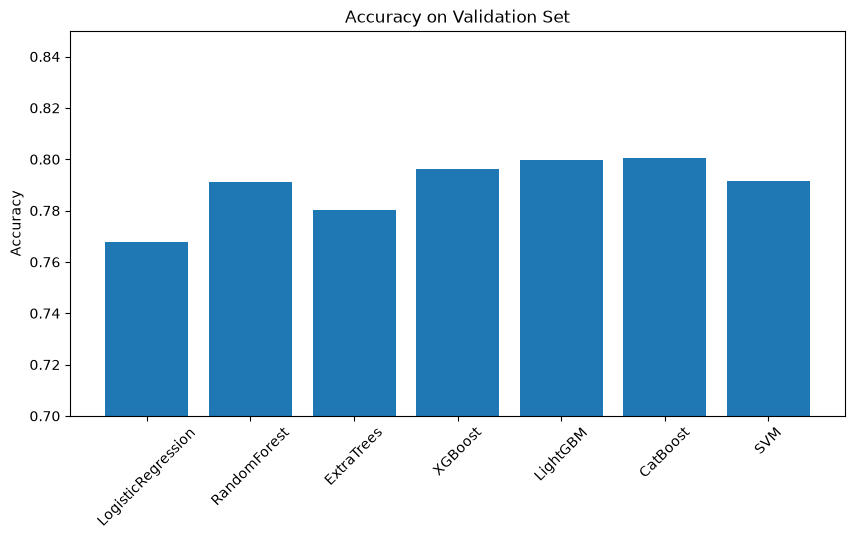

In [93]:
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    results[name] = acc
    print(f"{name}: Accuracy = {acc:.4f}")

# Trực quan hóa
plt.figure(figsize=(10,5))
plt.bar(results.keys(), results.values())
plt.ylim(0.7, 0.85)
plt.title('Accuracy on Validation Set')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.show()

Voting classifier (soft voting)

In [94]:
voting_clf = VotingClassifier(estimators=[
    ('lr', models['LogisticRegression']),
    ('rf', models['RandomForest']),
    ('xgb', models['XGBoost']),
    ('lgb', models['LightGBM']),
    ('svm', models['SVM'])
], voting='soft', n_jobs=-1)

voting_clf.fit(X_train, y_train)
y_pred_voting = voting_clf.predict(X_val)
acc_voting = accuracy_score(y_val, y_pred_voting)
print(f"Voting Classifier Accuracy: {acc_voting:.4f}")

Voting Classifier Accuracy: 0.8050


stacking classifier

In [95]:
base_models = [
    ('xgb', xgb.XGBClassifier(
        n_estimators=150,
        learning_rate=0.1,
        max_depth=5,
        subsample=0.7,
        colsample_bytree=0.7,
        reg_alpha=0.1,
        reg_lambda=1.0,
        min_child_weight=3,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    )),
    ('lgb', lgb.LGBMClassifier(
        n_estimators=150,
        learning_rate=0.1,
        num_leaves=31,
        subsample=0.7,
        colsample_bytree=0.7,
        reg_alpha=0.1,
        reg_lambda=1.0,
        min_child_weight=3,
        random_state=42,
        verbose=-1
    )),
    ('rf', RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )),
]

meta_model = LogisticRegression(max_iter=1000, random_state=42)

stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    n_jobs=-1
)

stacking_clf.fit(X_train, y_train)
y_pred_stacking = stacking_clf.predict(X_val)
acc_stacking = accuracy_score(y_val, y_pred_stacking)
print(f"Stacking Classifier Accuracy: {acc_stacking:.4f}")

Stacking Classifier Accuracy: 0.8045


bagging feat. decision tree

In [96]:
bagging_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    max_samples=0.8,
    random_state=42,
    n_jobs=-1
)
bagging_clf.fit(X_train, y_train)
y_pred_bagging = bagging_clf.predict(X_val)
acc_bagging = accuracy_score(y_val, y_pred_bagging)
print(f"Bagging Classifier Accuracy: {acc_bagging:.4f}")

Bagging Classifier Accuracy: 0.7930


adaboost

In [97]:
ada_clf = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)
ada_clf.fit(X_train, y_train)
y_pred_ada = ada_clf.predict(X_val)
acc_ada = accuracy_score(y_val, y_pred_ada)
print(f"AdaBoost Classifier Accuracy: {acc_ada:.4f}")

AdaBoost Classifier Accuracy: 0.7525



Bảng độ chính xác:
                    Accuracy  Rank
Voting              0.804968     1
Stacking            0.804508     2
CatBoost            0.800368     3
LightGBM            0.799908     4
XGBoost             0.796228     5
Bagging             0.793008     6
SVM                 0.791628     7
RandomForest        0.791168     8
ExtraTrees          0.780129     9
LogisticRegression  0.767709    10
AdaBoost            0.752530    11


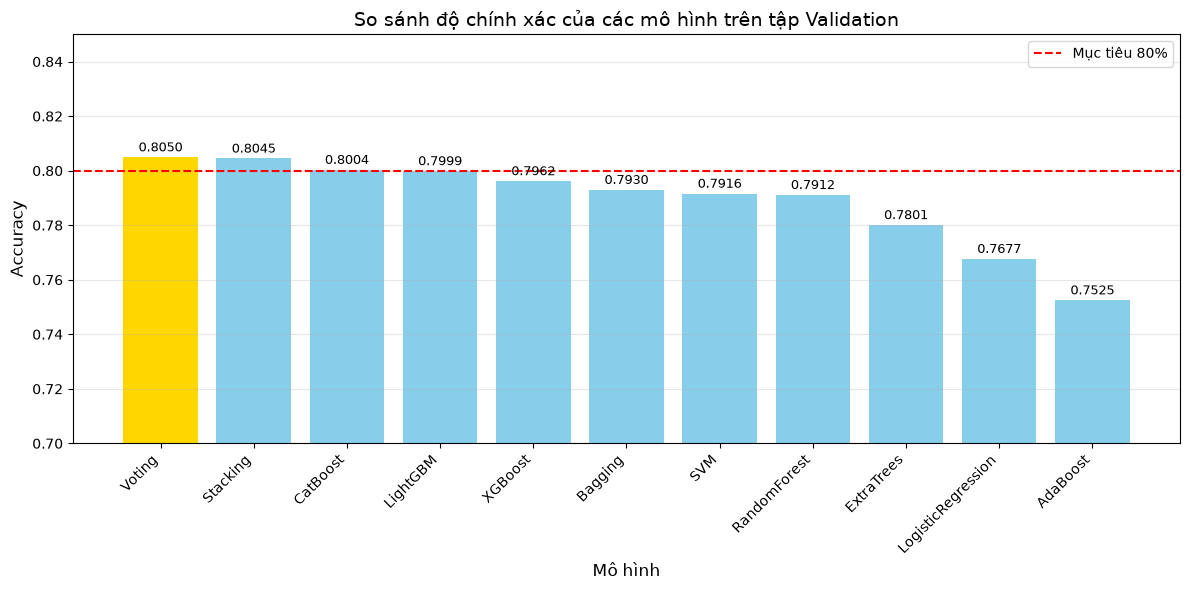

In [98]:
# Gộp tất cả kết quả
all_results = {}
all_results.update(results)  # Các mô hình cơ sở
all_results['Voting'] = acc_voting
all_results['Stacking'] = acc_stacking
all_results['Bagging'] = acc_bagging
all_results['AdaBoost'] = acc_ada

# Tạo DataFrame để so sánh
comparison_df = pd.DataFrame.from_dict(all_results, orient='index', columns=['Accuracy'])
comparison_df = comparison_df.sort_values(by='Accuracy', ascending=False)
comparison_df['Rank'] = range(1, len(comparison_df) + 1)

print("\nBảng độ chính xác:")
print(comparison_df)

# Vẽ biểu đồ so sánh
plt.figure(figsize=(12, 6))
bars = plt.bar(comparison_df.index, comparison_df['Accuracy'], 
               color=['gold' if i == 0 else 'skyblue' for i in range(len(comparison_df))])
plt.axhline(y=0.80, color='red', linestyle='--', label='Mục tiêu 80%')
plt.title('So sánh độ chính xác của các mô hình trên tập Validation', fontsize=14)
plt.xlabel('Mô hình', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.ylim(0.70, 0.85)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Thêm giá trị lên đầu cột
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.001,
             f'{height:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

Dự đoán trên test + tạo submission

In [99]:
best_model_name = max(all_results, key=all_results.get)
print(f"Mô hình tốt nhất: {best_model_name} với Accuracy = {all_results[best_model_name]:.4f}")

# Xác định mô hình tương ứng
if best_model_name == 'Voting':
    best_model = voting_clf
elif best_model_name == 'Stacking':
    best_model = stacking_clf
elif best_model_name == 'Bagging':
    best_model = bagging_clf
elif best_model_name == 'AdaBoost':
    best_model = ada_clf
elif best_model_name in ['XGBoost_Optimized', 'RandomForest_Optimized', 'LightGBM_Optimized']:
    best_model = grid_search.best_estimator_
elif best_model_name in models:
    best_model = models[best_model_name]
else:
    # Mặc định dùng Stacking
    print("Sử dụng Stacking Classifier làm mô hình mặc định")
    best_model = stacking_clf

print(f"\nĐang huấn luyện lại {best_model_name} trên toàn bộ dữ liệu train...")
# Train lại trên toàn bộ dữ liệu
best_model.fit(X_final, y)

# Dự đoán trên test
print("Đang dự đoán trên tập test...")
try:
    # Thử dự đoán xác suất
    y_test_proba = best_model.predict_proba(X_test_final)[:, 1]
    y_test_pred = (y_test_proba > 0.5)
except:
    # Nếu không có predict_proba, dùng predict
    y_test_pred = best_model.predict(X_test_final)
    y_test_proba = None

# Tạo submission
submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Transported': y_test_pred
})

# Đảm bảo kiểu dữ liệu đúng
submission['Transported'] = submission['Transported'].astype(bool)

# Lưu file
submission.to_csv('submission.csv', index=False)
print("\nĐã tạo file submission.csv thành công!")
print(f"Shape: {submission.shape}")
print("\n5 dòng đầu tiên:")
print(submission.head())

# Hiển thị phân phối dự đoán
print(f"\nPhân phối dự đoán:")
print(submission['Transported'].value_counts())
print(f"Tỷ lệ True: {submission['Transported'].mean():.2%}")

Mô hình tốt nhất: Voting với Accuracy = 0.8050

Đang huấn luyện lại Voting trên toàn bộ dữ liệu train...
Đang dự đoán trên tập test...

Đã tạo file submission.csv thành công!
Shape: (4277, 2)

5 dòng đầu tiên:
  PassengerId  Transported
0     0013_01         True
1     0018_01        False
2     0019_01         True
3     0021_01         True
4     0023_01         True

Phân phối dự đoán:
Transported
True     2285
False    1992
Name: count, dtype: int64
Tỷ lệ True: 53.43%


In [100]:
train_groups = set(train_processed['Group'].unique())
test_groups = set(test_processed['Group'].unique())
overlap = train_groups & test_groups

print(f"Số Group trong train: {len(train_groups)}")
print(f"Số Group trong test: {len(test_groups)}")
print(f"Số Group trùng nhau: {len(overlap)}")
print(f"Tỷ lệ trùng: {len(overlap) / len(train_groups):.2%}")

Số Group trong train: 6217
Số Group trong test: 3063
Số Group trùng nhau: 0
Tỷ lệ trùng: 0.00%
